A common thing for me to do, when using a tool developed by someone else, is to read through all the tedious details and try and understand where it all comes from and what the unstated assumptions are. While doing this recently I was motivated to ask, how do people estimate the explosive energy in a vapour cloud? It is an important question to ask when performing a hazard analysis, especially in the petrochemical industry -- often the worst case scenario is some chemical release leading to a vapour cloud explosion.

The standard references I looked at either provided an equation without giving any sense where it came from or, in one notable exception, gave an equation that (as far as I can tell) can't possibly be right. So I thought this might be fertile ground for investigation.

In [1]:
#| echo: false
using Markdown
using CairoMakie

post_theme = merge(theme_latexfonts(), Theme(palette = (color = to_colormap(:seaborn_muted6),)));

## The Gaussian dispersion model, a recap

Gaussian plumes are a common first dispersion model for chemical release screening tools. They are easy to implement, especially in spreadsheets, and have convenient mathematical properties that makes calculating the parameters relevant to a hazard screening simple. The cases where either the plume is grounded^[emitted at ground level and perfectly reflecting off the ground plane] or is free^[emitted high enough above the ground that the ground plane can be neglected entirely] are particularly convenient as the plume extents can be calculated directly.

For what follows I am going to examine a free plume -- the results are very similar for a grounded plume -- which is given by

$$ \chi = { w \over {2\pi u \sigma_y \sigma_z} } \exp \left( - \frac{1}{2} \left( \left(\frac{y}{\sigma_y}\right)^2 + \left(\frac{z}{\sigma_z}\right)^2 \right) \right) $$

Where the origin has been chosen to coincide with the release point. The standard assumptions for a Gaussian plume are:

1. The release has a constant mass emission rate of $w$
2. The release has no momentum or buoyancy
3. Advection is by a constant windspeed $u$ which is in the positive $x$ direction
4. Turbulence is captured by the parameters $\sigma_y$ and $\sigma_z$ which are functions of the downwind distance $x$

For a free plume it is further assumed that there is no ground plane, the z-axis extends infinitely up and down.

To actually use this model, we need a parametrization of $\sigma_y$ and $\sigma_z$ for which I am going to use the simple power law $\sigma_y = a x^b$ and $\sigma_z = c x^d$

In [2]:
#| output: false
# System parameters
w = 1 # kg/s
u = 1 # m/s

1

In [3]:
#| output: false
# Class D - Neutral atmospheric stability
a = 0.128
b = 0.905
c = 0.20
d = 0.76

0.76

In [4]:
#| output: false
σy(x) = a*x^b
σz(x) = c*x^d

σz (generic function with 1 method)

In [5]:
#| output: false
χ(x,y,z; w=w, u=u) = w*exp(-0.5*((y/σy(x))^2 + (z/σz(x))^2))/(2π*u*σy(x)*σz(x))

χ (generic function with 1 method)

Suppose I am interested in the region of the plume between two concentrations $\chi_1$ and $\chi_2$, these might be the upper flammability limit (UFL) and the lower flammability limit (LFL) (respectively). It doesn't really matter. But further suppose that I have both the concentrations and the point along the $x$ axis where the centerline concentration equals that concentration. This is the point where the isosurface crosses the $x$ axis.

This is typically the step along a hazard analysis or consequence analysis where calculating the potential explosive energy takes place.

In [6]:
#| output: false
x₁ = 10  # m
x₂ = 100 # m

100

In [7]:
#| output: false
χ₁ = χ(x₁,0,0)
χ₂ = χ(x₂,0,0)

0.0029079046794392043

## A survey of estimates of the mass of vapour clouds

At the level of screening tools, estimating the potential explosive energy in a vapour cloud typically involves estimating the mass of explosive material in the cloud[^definition], then calculating the energy from the specific enthalpy of combustion.

The CCPS tools [CHEF](https://www.aiche.org/ccps/resources/tools/risk-analysis-screening-tool-rast-and-chemical-hazard-engineering-fundamentals-chef/chef-overview) and [RAST](https://www.aiche.org/ccps/resources/tools/risk-analysis-screening-tool-rast-and-chemical-hazard-engineering-fundamentals-chef/rast-overview), the TNO Yellow Book[@bakkum-2005 4.78], and @vanbuijtenen-1980 give the mass of a vapour cloud as

$$ m_e = C \frac{w}{u} x_l $$

Where $m_l$ is the mass of the region defined by the concentration $\chi_l$ and $C$ is a constant, which generally depends upon atmospheric stability. If the explosive mass is taken to be the region between two concentrations $\chi_1$ and $\chi_2$ with $\chi_1 > \chi_2$ then $m_e = m_2 - m_1$

|                 | C                                           |
|-----------------|---------------------------------------------|
| CHEF & RAST     | 1                                           |
| TNO Yellow Book | ${ {f_{z2}(L) + 1} \over {f_{z2}(L) + 2} }$ |
| Van Buijtenen   | ${ {b + d} \over {b + d + 1 } }$            | 


[^definition]: How one defines the flammable mass of a vapour cloud varies significantly from author to author, depending on whether one takes it to be the *entire* region with a concentration greater than the LFL, some fraction of the LFL (1/2 is common), or only the region between the LFL and UFL.

@woodward-1998 gives the following as the rigorous method for plumes, specifically for a free plume it is

$$ m_e = 4 \left( \chi_1 - \chi_2 \right) \int_{x_1}^{x_2} \sigma_y^2 E\left( k^2 \right) dx $$

where $E \left( k^2 \right)$ is the [complete elliptic integral of the second kind](https://en.wikipedia.org/wiki/Elliptic_integral#Complete_elliptic_integral_of_the_second_kind) and $k$ is a function of $x$ and atmospheric stability.

## The mass of a Gaussian plume

The mass in the region of a Gaussian plume with a concentration greater than $\chi_l$ is given by the volume integral

$$ m = \iiint_V \chi dV $$

where

$$ V = \left\{ x,y,z \vert \chi \left(x,y,z\right) \ge \chi_l \right\} $$

The mass in a free plume is given by

$$ m_{free} = \iiint_V \chi dV = \int_0^{x_l} \int_{-y_l}^{y_l} \int_{-z_l}^{z_l} \chi_{free} dz dy dx $$

By symmetry this is equal to

$$ 2 \int_0^{x_l} \int_{-y_l}^{y_l} \int_{0}^{z_l} \chi_{free} dz dy dx $$

Recalling that the concentration in a grounded plume is twice that of a free plume

$$ m_{free} = 2 \int_0^{x_l} \int_{-y_l}^{y_l} \int_{0}^{z_l} \chi_{free} dz dy dx = \int_0^{x_l} \int_{-y_l}^{y_l} \int_{0}^{z_l} \chi_{grounded} dz dy dx = m_{grounded} $$

### Total mass

The total mass in the plume contained between the planes $x=0$ and $x=x_l$ is simply the integral

$$ m_T = \iiint_{V_T} \chi dV $$

$$ V_T = \left\{ x,y,z \vert 0 \le x \le x_l, \chi\left(x,y,z\right) \gt 0 \right\} $$

Which follows directly from properties of Gaussian functions

$$ m_T = \int_0^{x_l} \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} \chi dz dy dx $$

$$ m_T = \frac{w}{u} x_l $$

Which is the result used in CHEF v4.5 -- the total mass in the plume. This also presents a useful upper bound: the mass in the flammable region of the plume must be less than the total mass of the plume.

## The isosurface of a Gaussian plume

The isopleths for a free Gaussian plume are given by

$$ y_l = \pm \sigma_y \sqrt{K} $$

$$ z_l = \pm \sigma_z \sqrt{K} $$

where $K = 2 \log \left( w \over {2\pi u \sigma_y \sigma_z \chi_l } \right)$

The whole isosurface is defined by

$$ S = \left\{ x, y, z \bigg\vert \left(\frac{y}{\sigma_y}\right)^2 + \left(\frac{z}{\sigma_z}\right)^2 = K \right\} $$

These can be used directly, but a more general approach is to use marching squares to find the isopleth.

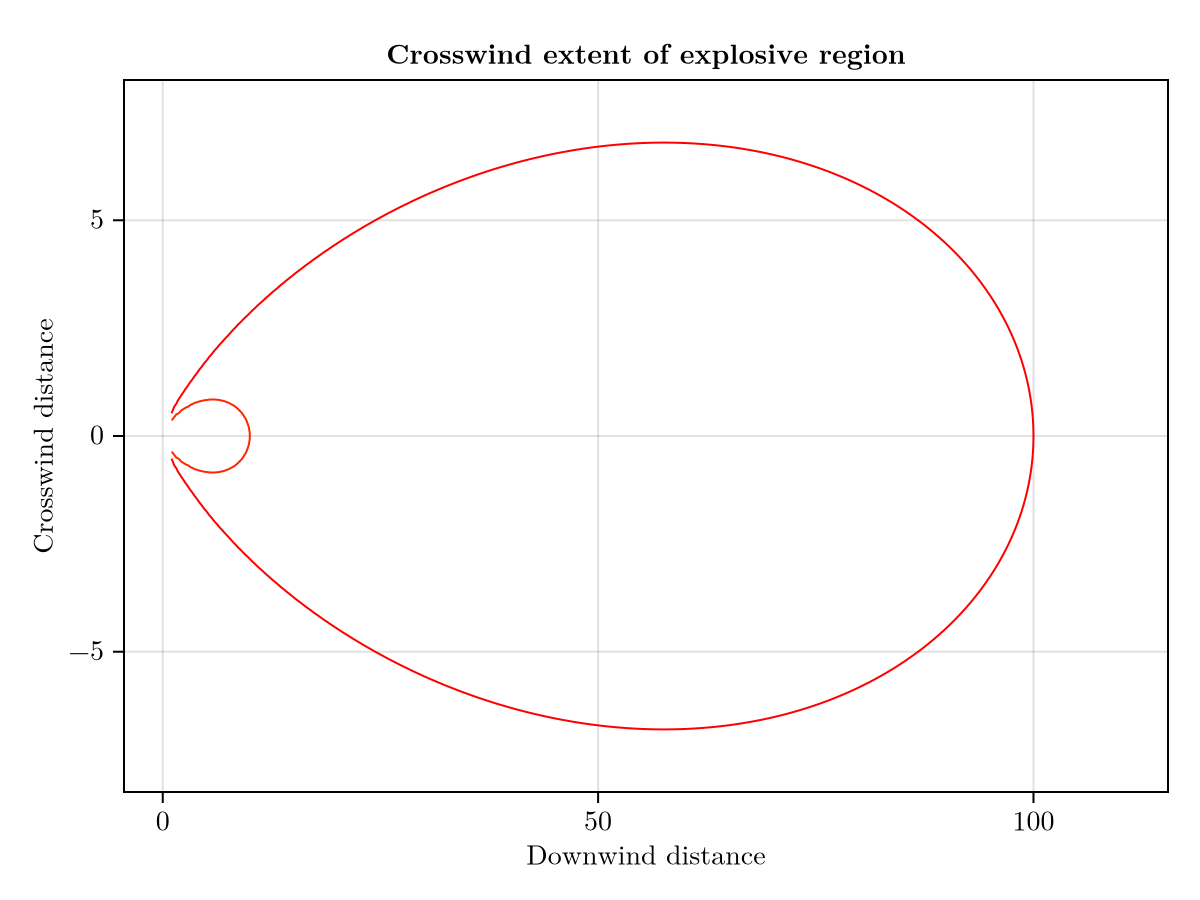

In [8]:
#| echo: false
#| label: fig-crosswind
#| fig-cap: "The crosswind extent of the region of interest."

with_theme(post_theme) do

    xs = LinRange(1,1.1*x₂,200)
    ys = LinRange(-7.5,7.5,100)
    cs = [ χ(x,y,0) for x in xs, y in ys]
    
    f = Figure()
    ax = Axis(f[1,1],
            title = "Crosswind extent of explosive region",
            xlabel = "Downwind distance",
            ylabel = "Crosswind distance",
            # dim1_conversion = Makie.UnitfulConversion(u"km"; units_in_label=true),
            # dim2_conversion = Makie.UnitfulConversion(u"m"; units_in_label=true),
            # limits = ((1/1000,ustrip(u"km",u*τ)),(-100,100))
    )
    
    levels = [χ₂, χ₁]
    
    ctr = contour!(ax, xs, ys, cs,
                   levels=levels,
                   colormap=(:hsv, 1.0),
                  # transparency=false,
                  # extendhigh = :auto
    )
    
    #Colorbar(f[1, 2], ctr, label="Concentration, mg/m³")
    
    f
end

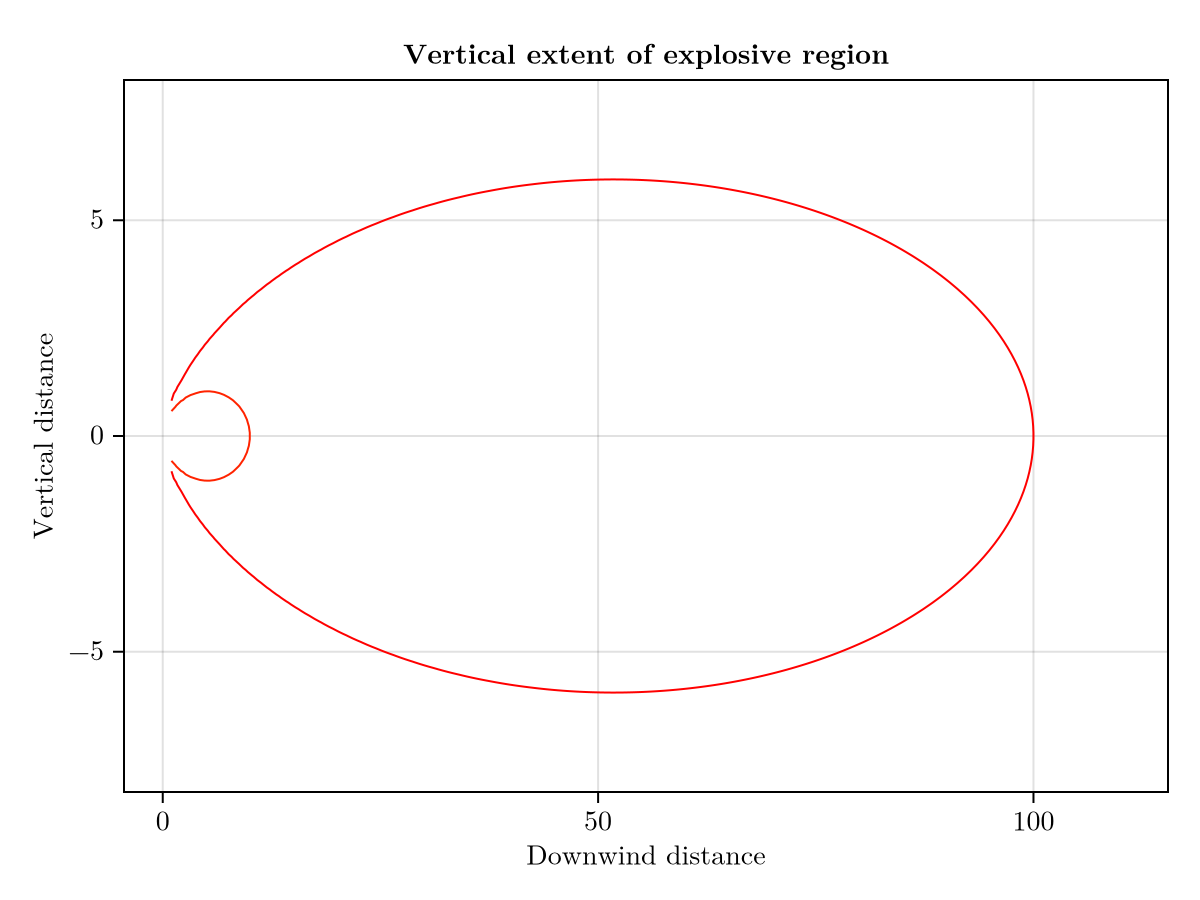

In [9]:
#| echo: false
#| label: fig-vertical
#| fig-cap: "The vertical extent of the region of interest."

with_theme(post_theme) do

    xs = LinRange(1,1.1*x₂,200)
    zs = LinRange(-7.5,7.5,100)
    cs = [ χ(x,0,z) for x in xs, z in zs]
    
    f = Figure()
    ax = Axis(f[1,1],
            title = "Vertical extent of explosive region",
            xlabel = "Downwind distance",
            ylabel = "Vertical distance",
            # dim1_conversion = Makie.UnitfulConversion(u"km"; units_in_label=true),
            # dim2_conversion = Makie.UnitfulConversion(u"m"; units_in_label=true),
            # limits = ((1/1000,ustrip(u"km",u*τ)),(-100,100))
    )
    
    levels = [χ(x₂,0,0), χ(x₁,0,0)]
    
    ctr = contour!(ax, xs, zs, cs,
                   levels=levels,
                   colormap=(:hsv, 1.0),
                  # transparency=false,
                  # extendhigh = :auto
    )
    
    #Colorbar(f[1, 2], ctr, label="Concentration, mg/m³")
    
    f
end

For a general plume one can find the surface using [marching tetrahedra](https://en.wikipedia.org/wiki/Marching_tetrahedra). In the following the surface for $\chi_2$ is calculated by marching tetrahedra, as shown in @fig-isosurface.

In [10]:
using Meshing: MarchingTetrahedra, isosurface
using GeometryBasics: Mesh, Point, Vec, Triangle, TriangleFace, volume

In [11]:
χ_safe(x,y,z) = isnan(χ(x,y,z)) ? 0.0 : χ(x,y,z);

In [12]:
xs = LinRange(0.0, x₂, 100)
ys = LinRange(-7.5, 7.5, 25)
zs = LinRange(-7.5, 7.5, 25)

χfield = [ χ_safe(x,y,z) - χ₂ for x in xs, y in ys, z in zs ]
pts,fcs = isosurface(χfield, MarchingTetrahedra(), xs, ys, zs);

In [13]:
msh = Mesh(Point.(pts), TriangleFace.(fcs))

Mesh{3, Float64, TriangleFace{Int64}}
    faces: 43472
    vertex position: 21740


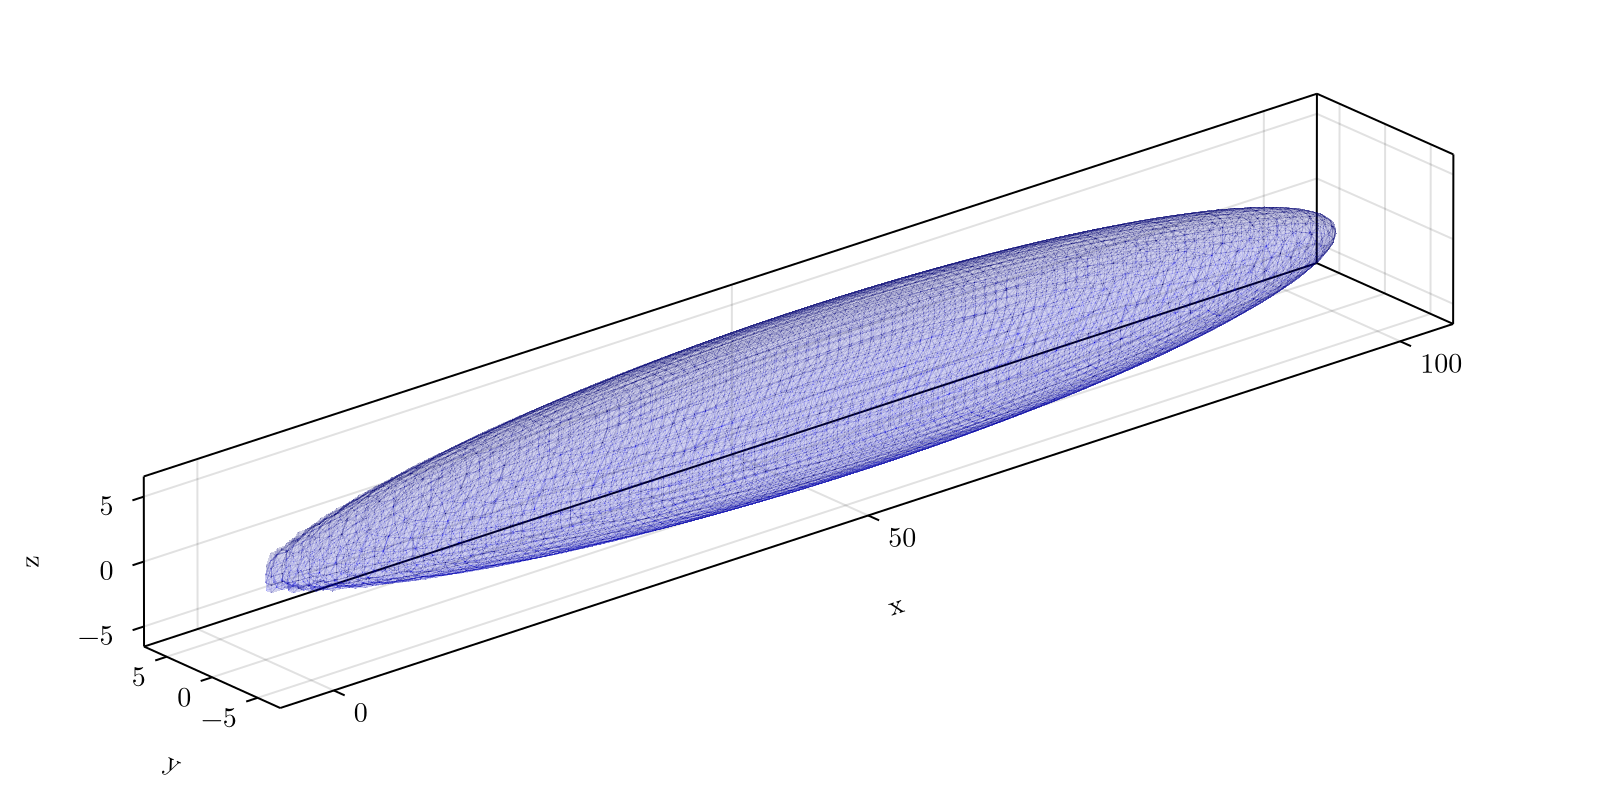

In [14]:
#| echo: false
#| label: fig-isosurface
#| fig-cap: "The χ₂ iso-surface, calculated by marching tetrahedra."

with_theme(post_theme) do

    f = Figure(size=(800,400))
    ax = Axis3(f[1, 1], aspect=:data)
    plt = mesh!(ax, msh; color=(:blue, 0.1), transparency=:true)
    f

end

If the potential explosive energy was being determined using the volume of the cloud, well we would be done. The volume of a meshed surface can be calculated directly

In [15]:
abs(volume(msh))

8085.175640305937

Presumably one could tetragonalize this mesh and calculate the volume integral of the mass through that. I will leave that as an exercise for the reader. For the particular case of a free plume that will be more work than is required.

## Direct numerical integration

The most direct approach to calculating the explosive mass is to numerically integrate over a rectangular region containing the plume [@woodward-1998 241]

$$
m_l = \iiint_{V} \chi dV = \int_{0}^{x_l} \int_{-y_l}^{y_l} \int_{-z_l}^{z_l} \begin{cases} 
          \chi & \chi \ge \chi_l \\
          0 & \chi \lt \chi_l
       \end{cases} dz dy dx
$$

This can be done directly using the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) in three dimensions.

In [16]:
#| output: false
@inline χ_inbounds(x,y,z; χₗ,w,u) = χ(x,y,z; w=w,u=u)≥χₗ ? χ(x,y,z; w=w,u=u) : 0.0

χ_inbounds (generic function with 1 method)

In [17]:
#| output: false
function mass🪤(xₗ; lower, upper, N=100, w=w, u=u)
    y_a, z_a = lower
    y_b, z_b = upper
    x_a, x_b = 0.0, xₗ

    Δx = (x_b - x_a)/N
    Δy = (y_b - y_a)/N
    Δz = (z_b - z_a)/N

    χₗ, Σχ = χ(xₗ,0,0; w=w, u=u), 0.0
    for i in 1:N, j in 1:N, k in 1:N
        xᵢ₋₁, xᵢ = x_a + (i-1)*Δx, x_a + i*Δx
        yⱼ₋₁, yⱼ = y_a + (j-1)*Δy, y_a + j*Δy
        zₖ₋₁, zₖ = z_a + (k-1)*Δz, z_a + k*Δz

        Σχ += ( χ_inbounds(xᵢ₋₁, yⱼ₋₁, zₖ₋₁; χₗ=χₗ, w=w, u=u) 
              + χ_inbounds(xᵢ₋₁, yⱼ₋₁, zₖ; χₗ=χₗ, w=w, u=u) 
              + χ_inbounds(xᵢ₋₁, yⱼ, zₖ₋₁; χₗ=χₗ, w=w, u=u) 
              + χ_inbounds(xᵢ₋₁, yⱼ, zₖ; χₗ=χₗ, w=w, u=u)
              + χ_inbounds(xᵢ, yⱼ₋₁, zₖ₋₁; χₗ=χₗ, w=w, u=u)
              + χ_inbounds(xᵢ₋₁, yⱼ₋₁, zₖ; χₗ=χₗ, w=w, u=u)
              + χ_inbounds(xᵢ, yⱼ, zₖ₋₁; χₗ=χₗ, w=w, u=u)
              + χ_inbounds(xᵢ₋₁, yⱼ, zₖ; χₗ=χₗ, w=w, u=u) )

    end

    return Σχ*Δx*Δy*Δz/8
end

mass🪤 (generic function with 1 method)

In [18]:
m🪤 = mass🪤(x₂; lower=[-7.5,-7.5], upper=[7.5,7.5]) - 
        mass🪤(x₁; lower=[-1.5,-1.5], upper=[1.5,1.5]);

In [19]:
#| echo: false
let

display(Markdown.parse("""
        The mass by trapezoidal rule is $(round(m🪤; digits=2))kg
        """))

end

The mass by trapezoidal rule is 55.77kg


The obvious downside of this approach is that it integrates over regions that are outside the plume isosurface with the same resolution as regions within the plume. Getting a good result requires a very fine grid and calculating a great many points which are ultimately discarded.

We can reduce the number of discards by taking advantage of what we know about the Gaussian plume: we know the vertical and crosswind isopleths. Introducing a change of variables $\xi$, $\zeta$ such that $\xi \in [-1,1]$ and $\zeta \in [-1,1]$ and

$$ y = \sigma_y \sqrt{K} \xi $$

$$ z = \sigma_z \sqrt{K} \zeta $$

$$
m_l = \iiint_{V} \chi dV = \int_{0}^{x_l} \int_{-1}^{1} \int_{-1}^{1} \begin{cases} 
          \sigma_y \sigma_z K \chi & \chi \ge \chi_l \\
          0 & \chi \lt \chi_l
       \end{cases} d\zeta d\xi dx
$$

where $K = 2 \log \left( w \over {2\pi u \sigma_y \sigma_z \chi_l } \right)$

This changes the domain of integration from a rectangular prism to one with a rectangular cross-section whose size is a function of $x$. It is somewhat more efficient, and doesn't require the user to pick a good bounding box.

In [20]:
#| output: false
function mass🪤2(xₗ; N=100, w=w, u=u)   
    χₗ = χ(xₗ,0,0; w=w, u=u)
    function integrand(x,ξ,ζ)
        K = 2*log(w/(2π*u*σy(x)*σz(x)*χₗ))
        y_lim = σy(x)*√(K)
        z_lim = σz(x)*√(K)
        y, z = y_lim*ξ, z_lim*ζ
        I = y_lim*z_lim*χ_inbounds(x,y,z; χₗ=χₗ, w=w, u=u)
        return isnan(I) ? 0.0 : I
    end

    x_a, x_b = 0.0, xₗ
    ξ_a, ξ_b = -1.0, 1.0
    ζ_a, ζ_b = -1.0, 1.0
    Δx = (x_b - x_a)/N
    Δξ = (ξ_b - ξ_a)/N
    Δζ = (ζ_b - ζ_a)/N

    Σχ = 0.0
    for i in 1:N, j in 1:N, k in 1:N
        xᵢ₋₁, xᵢ = x_a + (i-1)*Δx, x_a + i*Δx
        ξⱼ₋₁, ξⱼ = ξ_a + (j-1)*Δξ, ξ_a + j*Δξ
        ζₖ₋₁, ζₖ = ζ_a + (k-1)*Δζ, ζ_a + k*Δζ

        Σχ += ( integrand(xᵢ₋₁, ξⱼ₋₁, ζₖ₋₁) 
              + integrand(xᵢ₋₁, ξⱼ₋₁, ζₖ) 
              + integrand(xᵢ₋₁, ξⱼ, ζₖ₋₁) 
              + integrand(xᵢ₋₁, ξⱼ, ζₖ)
              + integrand(xᵢ, ξⱼ₋₁, ζₖ₋₁)
              + integrand(xᵢ₋₁, ξⱼ₋₁, ζₖ)
              + integrand(xᵢ, ξⱼ, ζₖ₋₁)
              + integrand(xᵢ₋₁, ξⱼ, ζₖ) )

    end

    return Σχ*Δx*Δξ*Δζ/8
end

mass🪤2 (generic function with 1 method)

In [21]:
m🪤2 = mass🪤2(x₂) - mass🪤2(x₁);

In [22]:
#| echo: false
let

display(Markdown.parse("""
        The mass by trapezoidal rule, with a change of variables, is $(round(m🪤2; digits=2))kg
        """))

end

The mass by trapezoidal rule, with a change of variables, is 55.73kg


This is still a very wasteful integration since it suffers from the curse of dimensionality. To come up with a somewhat reasonable answer requires evaluating the integrand $8 \times N^3$ times. A large proportion of those evaluations are still being thrown out, as they are outside the region of interest.

This could be sped up by parallelizing the calculations, which would allow for larger values of N to get more accurate results, but a more efficient approach is to use Monte Carlo integration.

In [23]:
using MCIntegration

In [24]:
function mass🎲(xₗ; w=w, u=u)
    χₗ = χ(xₗ,0,0; w=w, u=u)
    function integrand(x,ξ,ζ)
        K = 2*log(w/(2π*u*σy(x)*σz(x)*χₗ))
        y_lim = σy(x)*√(K)
        z_lim = σz(x)*√(K)
        y, z = y_lim*ξ, z_lim*ζ
        I = y_lim*z_lim*χ_inbounds(x,y,z; χₗ=χₗ, w=w, u=u)
        return isnan(I) ? 0.0 : I
    end
    
    xξζ = CompositeVar(Continuous(0.0,xₗ),
                       Continuous(-1.0,1.0),
                       Continuous(-1.0,1.0))
    res = integrate(((x, ξ, ζ), c)-> integrand(x[1],ξ[1],ζ[1]); var = xξζ)
    return res.mean[1]
end

mass🎲 (generic function with 1 method)

In [25]:
m🎲 = mass🎲(x₂) - mass🎲(x₁);

Total iterations * blocks 160: 100%|██████| Time: 0:00:02 (17.37 ms/it)


In [26]:
#| echo: false
let

display(Markdown.parse("""
        The mass by Monte Carlo, with a change of variables, is $(round(m🎲; digits=2))kg
        """))

end

The mass by Monte Carlo, with a change of variables, is 56.36kg


Both of these approaches have a similar relative error (spoilers!) but the Monte Carlo integration is much more efficient -- in time and memory.

In [27]:
using BenchmarkTools

In [28]:
🪤res = @benchmark mass🪤2(x₂)

BenchmarkTools.Trial: 1 sample with 1 evaluation per sample.
 Single result which took 9.444 s (11.24% GC) to evaluate,
 with a memory estimate of 9.10 GiB, over 607442648 allocations.

In [29]:
🎲res = @benchmark mass🎲(x₂)

BenchmarkTools.Trial: 30 samples with 1 evaluation per sample.
 Range (min … max):  161.499 ms … 184.335 ms  ┊ GC (min … max):  8.80% … 6.33%
 Time  (median):     165.566 ms               ┊ GC (median):    10.62%
 Time  (mean ± σ):   167.251 ms ±   5.510 ms  ┊ GC (mean ± σ):  10.25% ± 2.34%

  ▃    ▃▃█ ▃▃▃▃                                               ▃  
  █▁▁▇▇███▁████▇▇▇▁▁▁▇▇▁▁▇▁▁▁▇▇▁▁▁▁▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  161 ms           Histogram: frequency by time          184 ms <

 Memory estimate: 164.92 MiB, allocs estimate: 10748898.

The only reason I included the trapezoidal rule is that I saw it suggested in an online resource that, on reflection, I think may have been AI slop and so I'm not linking to it (I was going to have a much longer diatribe here about it too, so consider yourself saved). The moral of the story is don't use the trapezoidal rule for multidimensional integration unless you have some really compelling reason to do so.

The advantage to the Monte Carlo approach given above is that it will work pretty much out of the box for any plume. The error will be smaller the more tightly the domain of integration can be bound around the region where $\chi \ge \chi_l$, but it is in general pretty forgiving.

## Adaptive step-sizes with H Cubature

The other standard approach for multi-dimensional integration is adaptive cubature, for example h cubature. This approach really only works well when the bounds of integration are constants (e.g. the limits $y_l$ and $z_l$ do not depend on $x$) and when the function being integrated does not have abrupt step changes. Taking the integrand from above and just running h cubature over it will be terribly inefficient.

A better approach is to re-write the integral such that the integration is only over the region with $\chi \ge \chi_l$, and with an integrand that is smooth and continuous throughout. Firstly we re-write the integral.

$$m_l = \iint_V \chi dV = \int_0^{x_l} \iint_{\mathcal{E}} \chi dA dx $$

$$ \mathcal{E} = \left\{ y, z \bigg\vert \left( y \over \sigma_y \right)^2 + \left( z \over \sigma_z \right)^2 \le K\left( x \right) \right\} $$

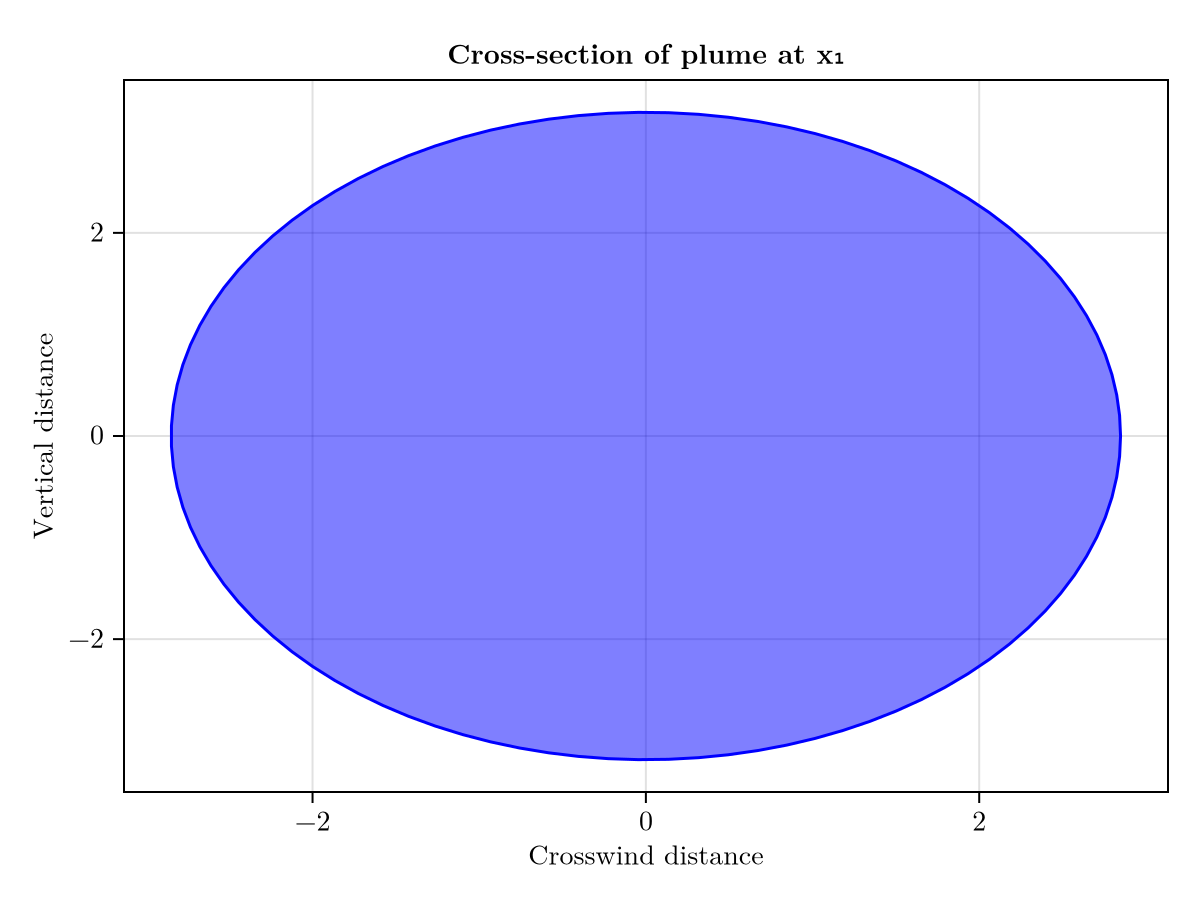

In [30]:
#| echo: false
#| label: fig-ellipse
#| fig-cap: "The cross-sectional area of the plume, an ellipse."

with_theme(post_theme) do
    K = 2*(log(w) - log(2π*χ₂*σy(x₁)*σz(x₁)*u))
    θs = LinRange(0,2π,100)
    ys = @. σy(x₁)*√(K)*cos(θs)
    zs = @. σz(x₁)*√(K)*sin(θs)
    
    f = Figure()
    ax = Axis(f[1,1],
            title = "Cross-section of plume at x₁",
            xlabel = "Crosswind distance",
            ylabel = "Vertical distance",
    )
    
    lines!(ax, ys, zs; color=:blue)
    poly!(Point2f.(zip(ys,zs)); color=(:blue,0.5))
    
    f
end

Note that $\mathcal{E}$ defines an ellipse, @fig-ellipse, which suggests the change of variables $\rho$, $\theta$ such that

$$ y = \sigma_y \sqrt{K} \rho \cos \theta $$

$$ z = \sigma_z \sqrt{K} \rho \sin \theta $$

and $\rho \in [0,1]$, $\theta \in [0, 2\pi]$

$$ m_l = \int_0^{x_l} \int_0^{2\pi} \int_0^1 \sigma_y \sigma_z K \chi \rho {d\rho} {d\theta} {dx} $$

This can be integrated directly with h cubature without involving any discontinuous functions.

In [31]:
using HCubature: hcubature

In [32]:
#| output: false
function mass📦(xₗ; w=w, u=u)
    lower = [0.0, 0.0, 0.0]
    upper = [1.0, 2π, xₗ]
    χₗ = χ(xₗ,0,0; w=w, u=u)
    
    function integrand(r)
        (ρ,θ,x) = r
        K = 2*(log(w) - log(2π*χₗ*σy(x)*σz(x)*u))
        y = σy(x)*√(K)*ρ*cos(θ)
        z = σz(x)*√(K)*ρ*sin(θ)
        return σy(x)*σz(x)*K*χ(x,y,z; w=w, u=u)*ρ
    end

    I, err = hcubature(integrand, lower, upper)
    return I
end

mass📦 (generic function with 1 method)

In [33]:
m📦 = mass📦(x₂) - mass📦(x₁);

In [34]:
#| echo: false
let

display(Markdown.parse("""
        The mass by H cubature is $(round(m📦; digits=2))kg
        """))

end

The mass by H cubature is 56.23kg


In [35]:
📦res = @benchmark mass📦(x₂)

BenchmarkTools.Trial: 208 samples with 1 evaluation per sample.
 Range (min … max):  19.541 ms … 35.658 ms  ┊ GC (min … max):  0.00% … 37.93%
 Time  (median):     25.003 ms              ┊ GC (median):    19.48%
 Time  (mean ± σ):   24.127 ms ±  2.908 ms  ┊ GC (mean ± σ):  13.37% ± 10.14%

     ▁                 ▄▂█▂                                    
  ▄▆▇█▇▄▄▃▃▁▃▁▁▂▁▁▁▂▃▂█████▆▆▃▂▃▃▂▁▂▁▂▁▂▁▁▁▂▁▁▂▁▁▂▁▁▁▁▁▁▁▁▂▁▂ ▃
  19.5 ms         Histogram: frequency by time        34.2 ms <

 Memory estimate: 23.05 MiB, allocs estimate: 1459221.

This is both significantly more accurate (spoilers!) and a dramatic improvement in both compute time and memory useage. Though at a cost that this is not as easily adapted to other plume types. For example, a Gaussian plume at some height above the ground with ground-reflection does not have a nice clean expression for the lower plume extent and the change of variables to polar coordinates doesn't work as nicely.

## Integrating out the cross-sectional area

You might get the sense now that I am leading you somewhere very specific. By choosing polar coordinates for the integration, and noting that for the Gaussian free plume the isopleths form an ellipse, it should immediately suggest that we could just...integrate this analytically. Substituting $\rho$, $\theta$ directly into the definition of $\chi$ gives

$$ m_l = \int_0^{x_l} \int_0^{2\pi} \int_0^1 \sigma_y \sigma_z K \chi \rho d\rho d\theta dx $$

$$ = \int_0^{x_l} \int_0^{2\pi} \int_0^1 \sigma_y \sigma_z K \left( \frac{w}{2\pi u \sigma_y \sigma_z} \exp \left( -\frac{K}{2} \rho^2 \right) \right) \rho d\rho d\theta dx $$

$$ = \int_0^{x_l} \int_0^{2\pi} \sigma_y \sigma_z \left[ \frac{w}{2\pi u \sigma_y \sigma_z} \left( 1 - \exp \left( -\frac{K}{2} \right) \right) \right] d\theta dx $$

$$ = \int_0^{x_l} \frac{w}{u} \left( 1 - \exp \left( -\frac{K}{2} \right) \right) dx $$

$$ m_l = \frac{w}{u} x_l - 2\pi \chi_l \int_0^{x_l} \sigma_y \sigma_z dx $$

The last integral is a simple one dimensional integral which can be done with QuadGK.

In [36]:
using QuadGK: quadgk

In [37]:
function mass🔴(xₗ; w=w, u=u)
    I, err = quadgk( t -> σy(t)*σz(t), 0, xₗ)
    return (w/u)*xₗ - 2π*χ(xₗ,0,0; w=w, u=u)*I
end

mass🔴 (generic function with 1 method)

In [38]:
m🔴 = mass🔴(x₂) - mass🔴(x₁);

For the special case where $\sigma_y = a x^b$ and $\sigma_z = c x^d$ the integral can be done analytically to arrive at

$$ m_l = { {b+d} \over {b+d+1} } \frac{w}{u} x_l $$

Which is the result from @vanbuijtenen-1980 given above. Similarly if we take $\sigma_y \propto x$ and $\sigma_z \propto x^{f_{z2}(L)}$ then

$$ m_l = { {f_{z2}(L) +1} \over {f_{z2}(L)+2} } \frac{w}{u} x_l $$

Which is the result from the TNO Yellow Book[@bakkum-2005].

In [39]:
mₑ = (w/u)*((b+d)/(b+d+1))*(x₂ - x₁);

In [40]:
#| echo: false
let

display(Markdown.parse("""
        The mass by QuadGK is $(round(m🔴; digits=2))kg, and the exact analytic solution is $(round(mₑ; digits=2))kg 
        """))

end

The mass by QuadGK is 56.23kg, and the exact analytic solution is 56.23kg 


In [41]:
🔴res = @benchmark mass🔴(x₂)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  21.956 μs …  13.849 ms  ┊ GC (min … max): 0.00% … 99.31%
 Time  (median):     29.064 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   29.891 μs ± 138.294 μs  ┊ GC (mean ± σ):  4.60% ±  0.99%

         ▁█▅▂        ▅█▇▅▂                                      
  ▂▄▂▂▂▂▁████▆▄▃▂▂▃▃▇█████▇▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  22 μs           Histogram: frequency by time         43.7 μs <

 Memory estimate: 24.86 KiB, allocs estimate: 1519.

It is definitely a little bit of cheating to point out that the simple one-dimensional integral is much more performant than any of the three integrations of the whole volume, see @tbl-perf.

In [42]:
#| echo: false
#| label: tbl-perf
#| tbl-cap: Performance of the integration methods.
let

display(Markdown.parse("""
|                  | Mass (kg)               | Error (%)                                  | Median Time (ms)                               |
|------------------|-------------------------|--------------------------------------------|------------------------------------------------|
| Trapezoidal Rule | $(round(m🪤2; digits=2)) | $( round(abs(1-m🪤2/mₑ)*100; digits=1) )% | $( round(median(🪤res).time*10^-6; digits=2) ) |
| Monte Carlo      | $(round(m🎲; digits=2)) | $( round(abs(1-m🎲/mₑ)*100; digits=2) )%   | $( round(median(🎲res).time*10^-6; digits=2) ) |
| H Cubature       | $(round(m📦; digits=2)) | $( round(abs(1-m📦/mₑ)*100; digits=8) )%   | $( round(median(📦res).time*10^-6; digits=2) ) |
| QuadGK           | $(round(m🔴; digits=2)) | $( round(abs(1-m🔴/mₑ)*100; digits=10) )%  | $( round(median(🔴res).time*10^-6; digits=2) ) |

"""))

end

|                  | Mass (kg) | Error (%) | Median Time (ms) |
| ----------------:| ---------:| ---------:| ----------------:|
| Trapezoidal Rule |     55.73 |      0.9% |          9443.63 |
|      Monte Carlo |     56.36 |     0.23% |           165.57 |
|       H Cubature |     56.23 |   1.0e-8% |             25.0 |
|           QuadGK |     56.23 |  5.0e-10% |             0.03 |


### The mass in a grounded plume

With a slight change, the integration over the cross-sectional area of a free plume can be modified to give us the mass in a grounded plume

$$ m_g = \int_0^{x_l} \int_0^{\pi} \int_0^1 \sigma_y \sigma_z K_g \chi_g \rho d\rho d\theta dx $$

where $K_g = 2 \log \left( w \over {\pi u \sigma_y \sigma_z \chi_{g,l} } \right)$

$$ = \int_0^{x_l} \int_0^{\pi} \int_0^1 \sigma_y \sigma_z K_g \left( \frac{w}{\pi u \sigma_y \sigma_z} \exp \left( -\frac{K_g}{2} \rho^2 \right) \right) \rho d\rho d\theta dx $$

$$ = \int_0^{x_l} \int_0^{\pi} \sigma_y \sigma_z \left[ \frac{w}{\pi u \sigma_y \sigma_z} \left( 1 - \exp \left( -\frac{K_g}{2} \right) \right) \right] d\theta dx $$

$$ = \int_0^{x_l} \frac{w}{u} \left( 1 - \exp \left( -\frac{K_g}{2} \right) \right) dx $$

$$ m_g = \frac{w}{u} x_l - \pi \chi_{g,l} \int_0^{x_l} \sigma_y \sigma_z dx = \frac{w}{u} x_l - 2 \pi \chi_{f,l} \int_0^{x_l} \sigma_y \sigma_z dx = m_f$$

The masses within the free iso-surface and grounded iso-surface which intersect the x-axis at $x_l$ are the same, as we expect, but the concentration which defines that iso-surface is not the same. An important distinction.

## The "rigorous" method

You may have noticed the absence of the rigorous method given by Woodward in the analysis above. The rigorous method looks quite different from the previous integrations, but is similarly easy to calculate using `QuadGK`.

As a reminder the "rigorous" method given by Woodward for a free plume is

$$ m_e = 4 \left( \chi_1 - \chi_2 \right) \int_{x_1}^{x_2} \sigma_y^2 E\left( k^2 \right) dx $$

with $k^2 = 1 - \left(\frac{\sigma_z}{\sigma_y}\right)^2$ and $E$ the complete elliptic integral of the second kind.

In [43]:
using SpecialFunctions: ellipe

In [44]:
k²(x) = 1 - (σz(x)/σy(x))^2

k² (generic function with 1 method)

In [45]:
I, err = quadgk( t -> σy(t)^2 * ellipe(k²(t)), x₁, x₂)

(3522.359412198113, 4.6837135414534714e-7)

In [46]:
m_rigorous = 4*(χ₁ - χ₂)*I;

In [47]:
m_rigorous

1853.438596397458

In [48]:
#| echo: false
let

display(Markdown.parse("""
That is far too high, it is $(round(m_rigorous/mₑ; digits=1))× the exact solution and $(round(m_rigorous/x₂; digits=1))× the entire mass in the plume at x₂.
"""))

end

That is far too high, it is 33.0× the exact solution and 18.5× the entire mass in the plume at x₂.


Clearly this doesn't work. So what's gone wrong? Referring to the original paper by @hesse-1991 the mass is given as

$$ m_e = \iiint_V \chi dV = \int_{x_1}^{x_2} \iint_{\mathcal{E}} \chi dA dx $$

$$ \mathcal{E} = \left\{ y, z \bigg\vert K_1 \le \left(\frac{y}{\sigma_y}\right)^2 + \left(\frac{z}{\sigma_z}\right)^2 \le K_2 \right\} $$

where $\mathcal{E}$ is the area between the ellipses defined by $\chi_1$ and $\chi_2$. 

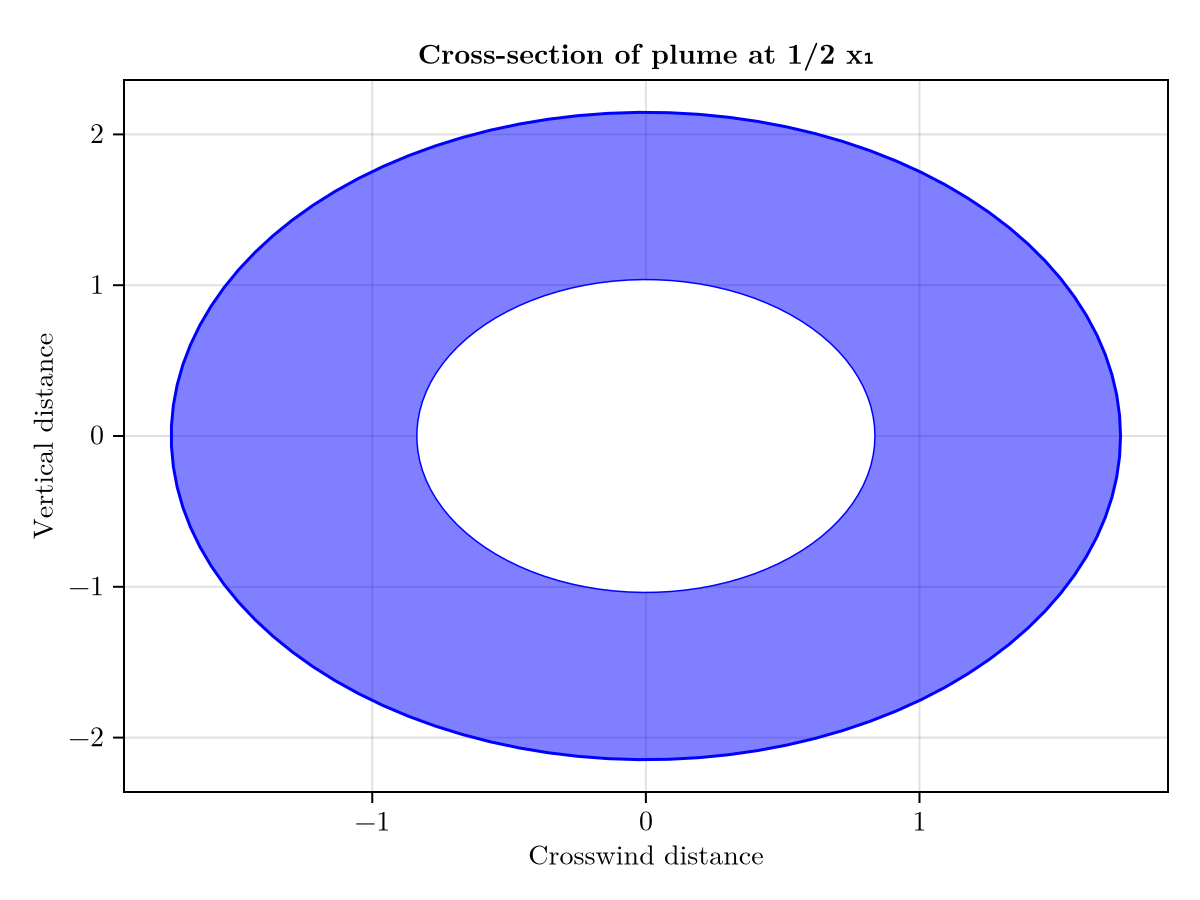

In [49]:
#| echo: false
#| label: fig-annulus
#| fig-cap: "The cross-sectional area of the plume, between the two ellipses."

with_theme(post_theme) do
    x′ = 0.5*x₁
    θs = LinRange(0,2π,100)

    K₁ = 2*(log(w) - log(2π*χ₁*σy(x′)*σz(x′)*u))
    y₁s = @. σy(x′)*√(K₁)*cos(θs)
    z₁s = @. σz(x′)*√(K₁)*sin(θs)
    
    K₂ = 2*(log(w) - log(2π*χ₂*σy(x′)*σz(x′)*u))
    y₂s = @. σy(x′)*√(K₂)*cos(θs)
    z₂s = @. σz(x′)*√(K₂)*sin(θs)
    
    f = Figure()
    ax = Axis(f[1,1],
            title = "Cross-section of plume at 1/2 x₁",
            xlabel = "Crosswind distance",
            ylabel = "Vertical distance",
    )

    lines!(ax, y₂s, z₂s; color=:blue)
    poly!(Point2f.(zip(y₂s,z₂s)); color=(:blue,0.5))
    
    lines!(ax, y₁s, z₁s; color=:blue)
    poly!(Point2f.(zip(y₁s,z₁s)); color=(:white,1.0))

    
    f
end

Hesse proposes that[@hesse-1991 equation 20]
$$ \iint_{\mathcal{E}} \chi dA = \int_{\sigma_y \sqrt{K_1}}^{\sigma_y \sqrt{K_2}} \chi p\left( x,y \right) dy $$

where $p(x,y)$ is the perimeter of the elliptical isopleth in the y-z plane defined by the concentration $\chi \left( x, y, 0 \right)$. That is to say, Hesse is integrating the cross-sectional area by treating it like a series of concentric, elliptical, rings with perimeter $p$ and width $dy$. For the free plume the perimeter is

$$ p(x,y) = 4 y E \left( k^2 \right) $$

Where $E \left( k^2 \right)$ is the [complete elliptic integral of the second kind](https://en.wikipedia.org/wiki/Elliptic_integral#Complete_elliptic_integral_of_the_second_kind) with the elliptic modulus given by $k^2 = 1 - \left(\frac{\sigma_z}{\sigma_y}\right)^2$, a constant with respect to $y$ and $z$.

Substituting in and making the change of variables to $\chi = \frac{w}{2\pi u \sigma_y \sigma_z} \exp \left( -\frac{1}{2} \left( \frac{y}{\sigma_y} \right)^2 \right)$

$$\iint_{\mathcal{E}} \chi dA = \int_{\sigma_y \sqrt{K_1}}^{\sigma_y \sqrt{K_2}} \chi p\left( x,y \right) dy $$

$$ = 4 \int_{\sigma_y \sqrt{K_1}}^{\sigma_y \sqrt{K_2}} \chi y E \left( k^2 \right) dy $$

$$ = 4 \int_{\chi_2}^{\chi_1} \chi y E \left( k^2 \right) { \sigma_y^2 \over {\chi y} } d\chi $$

$$ = 4 \int_{\chi_2}^{\chi_1} \sigma_y^2 E \left( k^2 \right) d\chi $$

$$ \iint_{\mathcal{E}} \chi dA = 4 \left(\chi_1 - \chi_2 \right) \sigma_y^2 E \left( k^2 \right) $$

From here the remainder of the derivation follows rather obviously....Unfortunately, this doesn't actually work as a method of integration. The problem is right at the very first step

$$\iint_{\mathcal{E}} \chi dA \ne \int_{\sigma_y \sqrt{K_1}}^{\sigma_y \sqrt{K_2}} \chi p\left( x,y \right) dy $$

To demonstrate this, consider the integration simply over the cross-sectional area. Hesse proposes that this relation holds

$$ \iint_{\mathcal{E}} dA = \int_0^{a} 4 y E \left( k^2 \right) dy $$

$$ \mathcal{E} = \left\{ y, z \bigg\vert \left(\frac{y}{a}\right)^2 + \left(\frac{z}{b}\right)^2 \le 1 \right\} $$

$$ k^2 = 1 - \left(\frac{b}{a}\right)^2 $$

That is, we should be able to use Hesse's technique to recover the area of an ellipse, since he is integrating over an elliptical cross-section. However, since $E \left( k^2 \right)$ is a constant, that's not what we get:

$$ A_{ellipse} = \int_0^{a} 4 y E \left( k^2 \right) dy $$

$$ = 2 a^2 E \left( k^2 \right) $$

But we know that the area of an ellipse is $\pi a b$. The only case in which Hesse's technique works is when $a = b$, since $E(0) = \frac{\pi}{2}$ (i.e. a circular cross-section).

There is another glaring flaw with how this integration is being done. Even were it the case that the integration over the cross-section was correct, the axial integration is being done over the region where the cross-section is no longer well defined. The ellipse that defines the inner boundary of our cross-sectional domain of integration *is not defined for* $x \gt x_1$. This is, in fact, *the definition of* $x_1$ ^[$x_1$ is the point where $K_1 = 0$, i.e. where the inner ellipse vanishes. At any point $x \gt x_1$ there is no point in the plume where $\chi = \chi_1$ and so the isopleth does not exist]. The only region over which the integration even makes sense is from $0 \le x \le x_1$, and yet the actual integration is being done over $x_1 \lt x \lt x_2$.

Even if the cross-sectional integration was adjusted such that the innner ellipse is ignored, and so the problem of being undefined in the region $x_1 \lt x \lt x_2$ is solved, it *still* doesn't work because it excludes the mass in the plume between $0 \le x \le x_1$ for which $\chi_2 \le \chi \lt \chi_1$. Clearly from @fig-crosswind and @fig-vertical, this is not a negligible region. 

One might be tempted by the logic

$$ m_e = m_2 - m_1 $$

$$ = \int_{0}^{x_2} \iint_{\mathcal{E_2}} \chi dA dx - \int_{0}^{x_1} \iint_{\mathcal{E_1}} \chi dA dx $$

$$ = \int_{x_1}^{x_2} \iint_{\mathcal{E}} \chi dA dx $$

But that only works if $\mathcal{E_1} = \mathcal{E_2}$, which is not the case in general.

It is possible this was fixed in errata that did not make it into the final publication. @spicer-1996 also reference Hesse but note the inclusion of "important author errata distributed at the meeting where the paper was presented". Regardless, what is published in Hesse and Woodward is wrong.

## Conclusions and recommendations

For a screening level analysis I would use the relation

$$ m_l = \frac{w}{u} x_l - 2\pi \chi_l \int_0^{x_l} \sigma_y \sigma_z dx $$

to calculate the mass within an isosurface defined by $x_l$. This gives some freedom in choice of dispersion parameters $\sigma_y$ and $\sigma_z$. The free plume choice is a useful simplification even when considering release points at some elevation where ground reflection is important. The free plume model, while ignoring the ground plane entirely, does capture much of the mass that would accumulate along the ground (by integrating over the region that "passes through" the ground in the free model).

Something that may be worthwhile to explore is whether the mass within the isosurface that intersects the x-axis at $x_l$ for a plume at some height $h$ with ground reflection is also the same as the mass in the grounded and free plumes. One would expect the *concentration* along the centerline to be somwhere between that of the grounded and free plumes, so it is certainly suggestive when the *mass* within the two plumes is identical. I don't seen an obvious way of doing this analytically, but it would be nice to have an answer to the question of "how wrong would I be if I just used the same $m_l$ equation for everything?"